In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import itertools
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scipy.stats as stats

sns.set(font_scale=2) 
sns.set_style("ticks")
import warnings
warnings.filterwarnings("ignore")

In [2]:
def preprocess_plot(df, cat_name , name,  palette, order, plotting = False):
    ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)']

    for column in ls:
        df[column] = pd.to_numeric(df[column])

        if column in ['isi_(ms)', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'AHP_(mV)']:
            param_df = df[df.I_zero != 'silent']
        
        
        else:
            param_df = df
        
        try:
            unique_cat = df[cat_name].unique()
            combos = list(itertools.combinations(unique_cat, 2))

            for combo in combos:
                should_plot = False
                # _, p = stats.ttest_ind(param_df[(param_df[cat_name] == combo[0])][column].dropna(),
                #                         param_df[(param_df[cat_name] == combo[1])][column].dropna(),
                #                     equal_var = False)

                _, p = stats.mannwhitneyu(param_df[(param_df[cat_name] == combo[0])][column].dropna(),
                                        param_df[(param_df[cat_name] == combo[1])][column].dropna())
                _, p_greater = stats.mannwhitneyu(param_df[(param_df[cat_name] == combo[0])][column].dropna(),
                                        param_df[(param_df[cat_name] == combo[1])][column].dropna(),alternative= 'greater')
                _, p_smaller = stats.mannwhitneyu(param_df[(param_df[cat_name] == combo[0])][column].dropna(),
                                        param_df[(param_df[cat_name] == combo[1])][column].dropna(),alternative= 'less')
            
                print(column, combo, p, p_greater, p_smaller)
               

           
        except ValueError:
            
            continue

        if plotting:
            try:
                print(param_df.groupby(cat_name)[column].mean())
                
                fig,ax = plt.subplots(figsize = (3.5,2.5))
            
                sns.swarmplot(x=cat_name, y =column, data= param_df, palette = palette, order = order, alpha = 0.7, size = 4)
                sns.boxplot(x=cat_name, y =column, data= param_df, palette = palette, order = order, boxprops=dict(alpha=0.5), width = 0.5)
                sns.despine()
                plt.title(column, pad = 20)
                plt.xticks(rotation = 90)
                plt.savefig(f'output_figures/{name}_{column}.png',dpi = 300, bbox_inches = 'tight')
                plt.show()
            except KeyError:
                pass
                

def proportion(df, column1, column2, cols):
    prop = pd.crosstab(df[column1], df[column2], margins = True).reset_index()
    prop = prop.set_index(column1)
    print(prop)
    prop = prop.iloc[:-1, :-1]
    stat, p, dof, expected  = stats.chi2_contingency(prop)
    print(p)
    
    prop = prop.apply(lambda x: x.div(x.sum()).mul(100), axis=1)
    
    
    prop = prop[cols]
    prop = prop.reset_index()
    return prop

def prop_plot(df, column):
    df.plot(x = column, 
              kind = 'bar', 
              stacked = True,  
              mark_right = False,
              color = ['black', 'darkgray','gray'],
              figsize = (3,5), alpha = 0.7)
    plt.xticks(rotation = 0)
    ax = plt.gca()
    plt.ylabel('Percentage (%)')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

def remove_outlier(df_in, col_name):
    q1 = df_in[col_name].quantile(0.25)
    q3 = df_in[col_name].quantile(0.75)
    iqr = q3-q1 #Interquartile range
    fence_low  = q1-1.5*iqr
    fence_high = q3+1.5*iqr
    df_out = df_in.loc[(df_in[col_name] > fence_low) & (df_in[col_name] < fence_high)]
    return df_out

# epnys analysis

In [3]:
ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)']

include_gal = True

df = pd.read_csv('ephys_analysis_MC.csv')
df['experiment_day'] = df['experiment_day'].apply(lambda x: str(x).upper()[:13])
df.loc[df.Behaviour_6hFD =='No_FD','Behaviour_6hFD'] = 'Pre'
# df.loc[df.Behaviour_6hFD.isin(['Agg+', 'Agg-']),'Behaviour_6hFD'] = 'Post'
df.rename(columns = {'Instant_freq_(Hz)_1/ISI':'Instant_freq_(Hz)'}, inplace =True)

cat = df.Behaviour_6hFD.unique()

if include_gal:
       gal = df[(df.Gal_positive == 'yes') & (df.Behaviour_6hFD == 'Pre')]
       no_gal = df[(df.Gal_positive == 'no') & (df.Behaviour_6hFD == 'Pre')]
       ephys = pd.concat([df[(df.Gal_positive.isin(['Unknown','no']) & (df.Behaviour_6hFD == 'Pre'))], df[df.Behaviour_6hFD != 'Pre']])
       sample_num= int(no_gal.shape[0]/4)
       ephys = pd.concat([ephys, gal.sample(n = sample_num, random_state = 62)]).reset_index(drop = True)

else:
       ephys = df[df.Gal_positive == 'Unknown']
# ephys.loc[ephys.Behaviour_6hFD.isin(['npy_10', 'npy_100']),'Behaviour_6hFD'] = 'npy'

ephys.to_csv('sampled_ephys_data.csv')

In [4]:
behav = pd.read_csv('ephys_behav.csv')
ephys_behav = pd.merge(ephys, behav, on  = 'ID_mouse')
ephys_behav.columns = [col.replace('(', '_').replace(')', '_') for col in ephys_behav.columns]
ephys_behav.columns = [col.replace(' ', '_').replace('-', '_') for col in ephys_behav.columns]

In [5]:
ephys_behav.columns

Index(['experiment_day', 'sex', 'Gal_positive', 'state', 'estrous_stage',
       'ID_mouse', 'Genotype', 'Behaviour_6hFD', 'Cm_pF_', 'Adaptive',
       'I_zero', 'I_zero_reclassified', '60mV', 'Firing_freq__Hz__I0',
       'Instant_freq__Hz_', 'isi__ms_', 'cat_categ', 'CaT', 'Ih',
       'Ih_at__120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak',
       'area_mV_ms_', 'rheobase_at__60mV__pA_', 'AHP__mV_', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude_pA_',
       'sPSCs_Rise_time', 'sPSCs__decay_', 'AC_I0', 'AC__60', 'Comments',
       'estrous_confirmation', 'pup_intro', 'contact', 'attack',
       'contact_latency', 'attack_latency', 'attack_since_contact'],
      dtype='object')

In [6]:
percent_columns = ['Ih_at__120mV', 'CaT', 'Adaptive', 'Firing_freq__Hz__I0'] 
percentages_df = pd.DataFrame(index=ephys_behav['ID_mouse'].unique())

for column in percent_columns:
    percentages = ephys_behav.groupby('ID_mouse')[column].apply(lambda x: (x == 0).sum() / len(x) * 100)
    percentages_df[column + '_percent_nonzero'] = percentages

silent_percentages = ephys_behav.groupby('ID_mouse')['I_zero_reclassified'].apply(lambda x: (x == 'silent').sum() / len(x) * 100).reset_index(name='I_zero_reclassified' + '_percent_silent')
percentages_df = percentages_df.reset_index()
percentages_df.rename(columns={'index': 'ID_mouse'}, inplace=True)
percentages_df = pd.merge(percentages_df, silent_percentages, on='ID_mouse', how='outer')

percentages_df = pd.merge(percentages_df, behav, on = 'ID_mouse')




In [7]:
for y in percentages_df.columns[1:-6]:
    if y != 'attack_since_contact':  # Skip the contact_latency column
        formula = 'attack_since_contact ~ ' + y
        try:
            model = smf.ols(formula, data=percentages_df).fit()
            anova_results = sm.stats.anova_lm(model, typ=2)
            
            if model.pvalues[y] <0.05:
                print(model.pvalues[y], y, model.rsquared)

                sns.lmplot(x = 'attack_since_contact', y = y, data = percentages_df)
           
        except Exception as e:
            continue

0.03635851790913461 sPSC_Amplitude_pA_ 0.2603988087081557


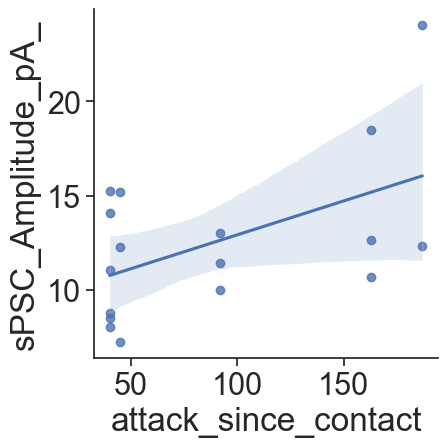

In [11]:
#ephys correlation with behaviour metric
for y in ephys_behav.columns[8:-8]:
    if y != 'attack_since_contact':  # Skip the contact_latency column
        formula = 'attack_since_contact ~ ' + y
        try:
            model = smf.ols(formula, data=ephys_behav).fit()
            anova_results = sm.stats.anova_lm(model, typ=2)
            
            if model.pvalues[y] <0.05:
                print(model.pvalues[y], y, model.rsquared)

                sns.lmplot(x = 'attack_since_contact', y = y, data = ephys_behav)
           
        except Exception as e:
            continue
    

In [9]:
ephys.Behaviour_6hFD.unique()

array(['Pre', 'Agg+', 'Agg-', 'npy_antag', 'npy1r_antag', 'npy2r_antag',
       'npy_10_paired', 'npy_10', 'npy_100_paired', 'npy_100',
       'agrp_100_paired', 'agrp_100', 'ZD7288', 'ZD7288_20'], dtype=object)

## all properties

Cm(pF) ('Pre', 'Agg+') 0.2112995473337107 0.8979576849251809 0.10564977366685535
Firing_freq_(Hz)_I0 ('Pre', 'Agg+') 0.010819464803954192 0.005409732401977096 0.9946686513651362
Firing_freq_(Hz)_I0 ('Pre', 'Agg-') 0.050500440681557957 0.9751259290618666 0.025250220340778978
Firing_freq_(Hz)_I0 ('Pre', 'npy1r_antag') 0.2573383694997692 0.8730045785365232 0.1286691847498846
Firing_freq_(Hz)_I0 ('Pre', 'npy2r_antag') 0.9719814151577115 0.48599070757885576 0.5180095295436465
Firing_freq_(Hz)_I0 ('Pre', 'npy_10') 0.7522137312931874 0.6269229742061785 0.3761068656465937
Firing_freq_(Hz)_I0 ('Pre', 'ZD7288') 0.00160254915119926 0.00080127457559963 0.9992275666160393
Firing_freq_(Hz)_I0 ('Agg+', 'Agg-') 0.000409831745363416 0.9998084262920238 0.000204915872681708
Firing_freq_(Hz)_I0 ('Agg+', 'npy1r_antag') 0.01378110226214151 0.9935433990468484 0.006890551131070755
Firing_freq_(Hz)_I0 ('Agg+', 'npy2r_antag') 0.11879034695155981 0.9441681591845452 0.059395173475779904
Firing_freq_(Hz)_I0 ('Agg+

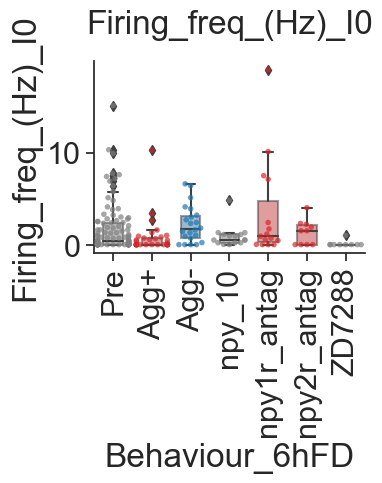

Instant_freq_(Hz) ('Pre', 'Agg+') 0.007126302284415039 0.0035631511422075197 0.9964908057368393
Instant_freq_(Hz) ('Pre', 'Agg-') 0.13791987695468466 0.9318884502067931 0.06895993847734233
Instant_freq_(Hz) ('Pre', 'npy1r_antag') 0.3387879475549421 0.8326192727914826 0.16939397377747106
Instant_freq_(Hz) ('Pre', 'npy2r_antag') 1.0 0.5040032170558973 0.5
Instant_freq_(Hz) ('Pre', 'npy_10') 0.8074135310571166 0.5993853040912118 0.4037067655285583
Instant_freq_(Hz) ('Pre', 'ZD7288') 0.002066214299640664 0.001033107149820332 0.9990033333739913
Instant_freq_(Hz) ('Agg+', 'Agg-') 0.0010172795558072499 0.9995225093029435 0.0005086397779036249
Instant_freq_(Hz) ('Agg+', 'npy1r_antag') 0.011311535506048284 0.9947083114917555 0.005655767753024142
Instant_freq_(Hz) ('Agg+', 'npy2r_antag') 0.142267991566083 0.9329710314863808 0.0711339957830415
Instant_freq_(Hz) ('Agg+', 'npy_10') 0.02033905481943857 0.9904354192558076 0.010169527409719286
Instant_freq_(Hz) ('Agg+', 'ZD7288') 0.09900021305885116 0

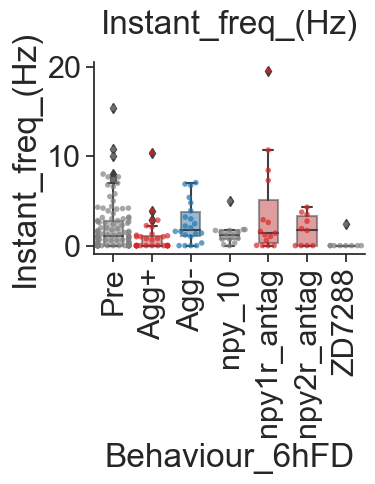

isi_(ms) ('Pre', 'Agg+') 0.8015286410640747 0.6033646479485788 0.40076432053203737
isi_(ms) ('Pre', 'Agg-') 0.054024744647440136 0.027012372323720068 0.9735812892422088
isi_(ms) ('Pre', 'npy1r_antag') 0.292912278038327 0.1464561390191635 0.8563160199130027
isi_(ms) ('Pre', 'npy2r_antag') 0.22888241165487228 0.11444120582743614 0.889006725839082
isi_(ms) ('Pre', 'npy_10') 0.19083431548398933 0.9064568697851287 0.09541715774199466
isi_(ms) ('Pre', 'ZD7288') 0.9610389610389612 0.5324675324675325 0.4805194805194806
isi_(ms) ('Agg+', 'Agg-') 0.014668259625073753 0.007334129812536876 0.9933683991320869
isi_(ms) ('Agg+', 'npy1r_antag') 0.31716652052312344 0.15858326026156172 0.8529322442295124
isi_(ms) ('Agg+', 'npy2r_antag') 0.03645142267433289 0.018225711337166446 0.9853678313430635
isi_(ms) ('Agg+', 'npy_10') 0.4711785048105669 0.7776359014844196 0.23558925240528344
isi_(ms) ('Agg+', 'ZD7288') 0.75 0.375 0.6875
isi_(ms) ('Agg-', 'npy1r_antag') 0.6566808075579458 0.6868119494339487 0.328340

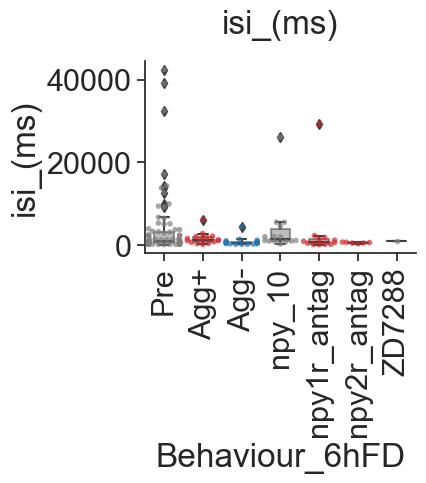

CaT ('Pre', 'Agg+') 0.49563408102644235 0.24781704051322118 0.7546394601283846
CaT ('Pre', 'Agg-') 0.3954543611558381 0.8047766579041866 0.19772718057791905
CaT ('Pre', 'npy1r_antag') 0.5461647859931317 0.27308239299656584 0.7307632968675444
CaT ('Pre', 'npy2r_antag') 0.2874387902140235 0.14371939510701176 0.8596247040614016
CaT ('Pre', 'npy_10') 0.04651313339583601 0.023256566697918004 0.9773971415898108
CaT ('Pre', 'ZD7288') 0.726065942091648 0.363032971045824 0.6427932754538841
CaT ('Agg+', 'Agg-') 0.1718067166849695 0.9173222357924475 0.08590335834248475
CaT ('Agg+', 'npy1r_antag') 0.9086094786774864 0.5570487143419316 0.4543047393387432
CaT ('Agg+', 'npy2r_antag') 0.5920321732352896 0.2960160866176448 0.7175535889345224
CaT ('Agg+', 'npy_10') 0.18520400662349512 0.09260200331174756 0.9125817910565133
CaT ('Agg+', 'ZD7288') 0.8865276989284464 0.5727855607326532 0.4432638494642232
CaT ('Agg-', 'npy1r_antag') 0.16745288464179808 0.08372644232089904 0.9212747103262406
CaT ('Agg-', 'np

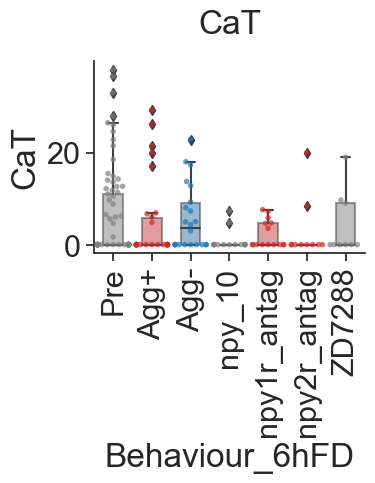

Ih_at_-120mV ('Pre', 'Agg+') 0.016953540388972527 0.008476770194486264 0.9916729271757764
Ih_at_-120mV ('Pre', 'Agg-') 0.5161858338475181 0.7444903205863516 0.2580929169237591
Ih_at_-120mV ('Pre', 'npy1r_antag') 0.895539682433509 0.4477698412167545 0.5562221137720073
Ih_at_-120mV ('Pre', 'npy2r_antag') 0.3510377171721971 0.17551885858609856 0.8277385787060498
Ih_at_-120mV ('Pre', 'npy_10') 0.04298660120520486 0.02149330060260243 0.9790234317721149
Ih_at_-120mV ('Pre', 'ZD7288') 0.00038696578446780085 0.00019348289223390043 0.9998162881782852
Ih_at_-120mV ('Agg+', 'Agg-') 0.0012473463277721786 0.9994148291751188 0.0006236731638860893
Ih_at_-120mV ('Agg+', 'npy1r_antag') 0.14420227060743224 0.9311299174986739 0.07210113530371612
Ih_at_-120mV ('Agg+', 'npy2r_antag') 0.2714397846596408 0.8709160224225923 0.1357198923298204
Ih_at_-120mV ('Agg+', 'npy_10') 0.7891993382904234 0.3945996691452117 0.614724808927064
Ih_at_-120mV ('Agg+', 'ZD7288') 0.0029161894382185396 0.0014580947191092698 0.998

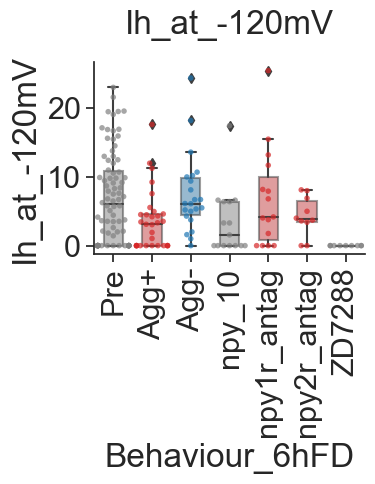

AP_ampl ('Pre', 'Agg+') 0.3025141906911134 0.1512570953455567 0.8517823195739602
AP_ampl ('Pre', 'Agg-') 0.6484995979902848 0.3242497989951424 0.6799417659697051
AP_ampl ('Pre', 'npy1r_antag') 0.0019617391708031686 0.0009808695854015843 0.9990672479543676
AP_ampl ('Pre', 'npy2r_antag') 0.16993115240275336 0.08496557620137668 0.9183991408949566
AP_ampl ('Pre', 'npy_10') 0.004388294648604545 0.0021941473243022726 0.9978978308015353
AP_ampl ('Pre', 'ZD7288') 0.6150079488107387 0.30750397440536936 0.7118576681070565
AP_ampl ('Agg+', 'Agg-') 0.7585816773946292 0.6343895545982985 0.3792908386973146
AP_ampl ('Agg+', 'npy1r_antag') 0.033761671550520726 0.016880835775260363 0.9850611958452546
AP_ampl ('Agg+', 'npy2r_antag') 0.7260097706731109 0.36300488533655545 0.6657885559460706
AP_ampl ('Agg+', 'npy_10') 0.2132192152945539 0.10660960764727695 0.9012032226445372
AP_ampl ('Agg+', 'ZD7288') 1.0 0.5859309517013473 0.5
AP_ampl ('Agg-', 'npy1r_antag') 0.006323780925748658 0.003161890462874329 0.99

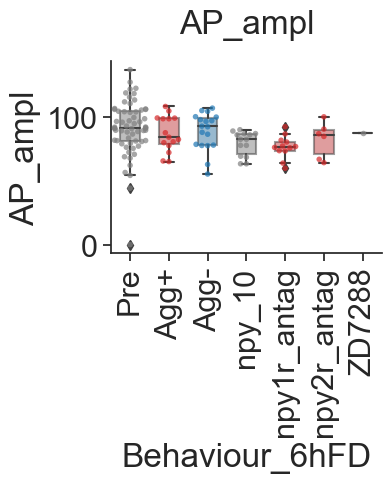

AP_halfwidth ('Pre', 'Agg+') 0.46219593535882597 0.7729156323170646 0.23109796767941299
AP_halfwidth ('Pre', 'Agg-') 0.04959538934130666 0.02479769467065333 0.9758829953731449
AP_halfwidth ('Pre', 'npy1r_antag') 0.8858255259367204 0.4429127629683602 0.5630485366741597
AP_halfwidth ('Pre', 'npy2r_antag') 0.8846865050190295 0.44234325250951473 0.5664500329259963
AP_halfwidth ('Pre', 'npy_10') 0.4113404558415319 0.20567022792076595 0.798238072740345
AP_halfwidth ('Pre', 'ZD7288') 0.7332069215467361 0.36660346077336803 0.6545644481077114
AP_halfwidth ('Agg+', 'Agg-') 0.04087328572937924 0.02043664286468962 0.981283253064442
AP_halfwidth ('Agg+', 'npy1r_antag') 0.7142261743773299 0.35711308718866497 0.6609330647740822
AP_halfwidth ('Agg+', 'npy2r_antag') 0.6221804511278195 0.31109022556390975 0.7153545628777827
AP_halfwidth ('Agg+', 'npy_10') 0.2650982114145718 0.1325491057072859 0.8765934386227345
AP_halfwidth ('Agg+', 'ZD7288') 0.875 0.4375 0.625
AP_halfwidth ('Agg-', 'npy1r_antag') 0.188

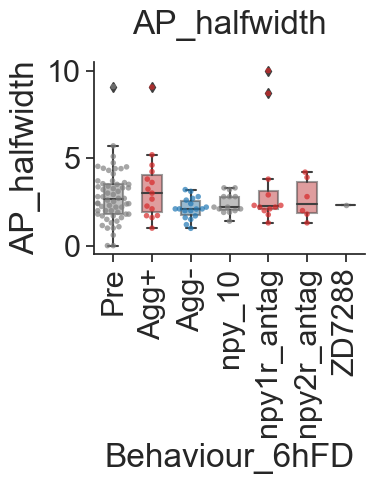

AP_time_to_peak ('Pre', 'Agg+') 0.43721735287798613 0.21860867643899307 0.7852238117184271
AP_time_to_peak ('Pre', 'Agg-') 0.8469049089292453 0.42345245446462265 0.5811241570554536
AP_time_to_peak ('Pre', 'npy1r_antag') 0.03377040596934124 0.9837294238986058 0.01688520298467062
AP_time_to_peak ('Pre', 'npy2r_antag') 0.344590387533354 0.8332564822611037 0.172295193766677
AP_time_to_peak ('Pre', 'npy_10') 0.2762024722179164 0.8648780274336905 0.1381012361089582
AP_time_to_peak ('Pre', 'ZD7288') 0.48448574129036415 0.24224287064518207 0.774885877787864
AP_time_to_peak ('Agg+', 'Agg-') 0.46913433639048585 0.7763974163092341 0.23456716819524293
AP_time_to_peak ('Agg+', 'npy1r_antag') 0.09169581650975384 0.9586653587277925 0.04584790825487692
AP_time_to_peak ('Agg+', 'npy2r_antag') 0.2931139556733102 0.8705911857252518 0.1465569778366551
AP_time_to_peak ('Agg+', 'npy_10') 0.2380676377215949 0.8894348176760429 0.11903381886079745
AP_time_to_peak ('Agg+', 'ZD7288') 1.0 0.5432500699486125 0.543

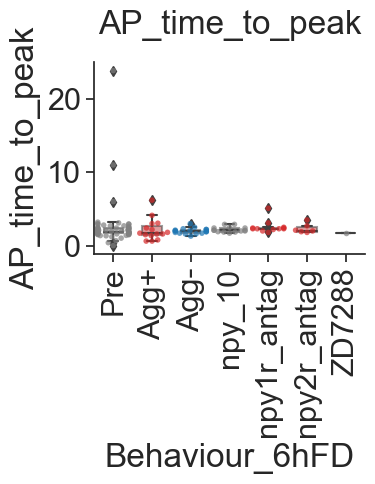

area(mV_ms) ('Pre', 'Agg+') 0.7991136298069239 0.39955681490346195 0.6054753662871157
area(mV_ms) ('Pre', 'Agg-') 0.016837642364698622 0.008418821182349311 0.9918454107492525
area(mV_ms) ('Pre', 'npy1r_antag') 0.2426447163920502 0.1213223581960251 0.8816520767739248
area(mV_ms) ('Pre', 'npy2r_antag') 0.30722417858225015 0.15361208929112508 0.8515310024491404
area(mV_ms) ('Pre', 'npy_10') 0.06639667441265373 0.03319833720632687 0.9677952215617482
area(mV_ms) ('Pre', 'ZD7288') 0.538761861912151 0.2693809309560755 0.7487517787940509
area(mV_ms) ('Agg+', 'Agg-') 0.3027726388020737 0.15138631940103686 0.8569381786233167
area(mV_ms) ('Agg+', 'npy1r_antag') 0.6083530708674068 0.3041765354337034 0.7126790115207389
area(mV_ms) ('Agg+', 'npy2r_antag') 0.5591773415993337 0.27958867079966687 0.7459948588186514
area(mV_ms) ('Agg+', 'npy_10') 0.47112381425774463 0.23556190712887232 0.7776639787284418
area(mV_ms) ('Agg+', 'ZD7288') 1.0 0.5859309517013473 0.5
area(mV_ms) ('Agg-', 'npy1r_antag') 0.9831

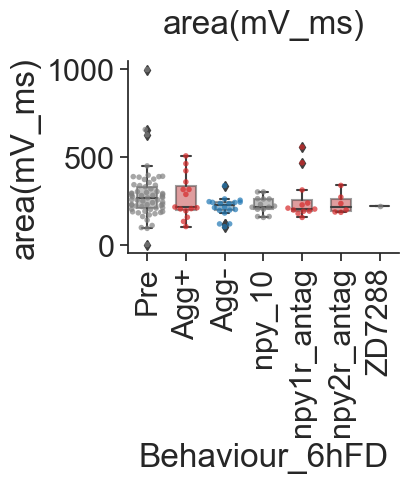

rheobase_at_-60mV_(pA) ('Pre', 'Agg+') 0.11034275446826022 0.9457450943609136 0.05517137723413011
rheobase_at_-60mV_(pA) ('Pre', 'Agg-') 0.14643851650205936 0.9282479696056212 0.07321925825102968
rheobase_at_-60mV_(pA) ('Pre', 'npy1r_antag') 0.21018602260282315 0.8973641031945495 0.10509301130141158
rheobase_at_-60mV_(pA) ('Pre', 'npy2r_antag') 0.4816368314688234 0.7643081070132076 0.2408184157344117
rheobase_at_-60mV_(pA) ('Pre', 'npy_10') 0.3075583468392078 0.8493010473891425 0.1537791734196039
rheobase_at_-60mV_(pA) ('Pre', 'ZD7288') 0.03158113135357213 0.015790565676786064 0.984937649879765
rheobase_at_-60mV_(pA) ('Agg+', 'Agg-') 0.8517483123001515 0.42587415615007573 0.5814393237099433
rheobase_at_-60mV_(pA) ('Agg+', 'npy1r_antag') 0.8826170792299943 0.44130853961499716 0.5683838921972741
rheobase_at_-60mV_(pA) ('Agg+', 'npy2r_antag') 0.6914016646419245 0.34570083232096227 0.6654882241487565
rheobase_at_-60mV_(pA) ('Agg+', 'npy_10') 0.32297044507062334 0.16148522253531167 0.844208

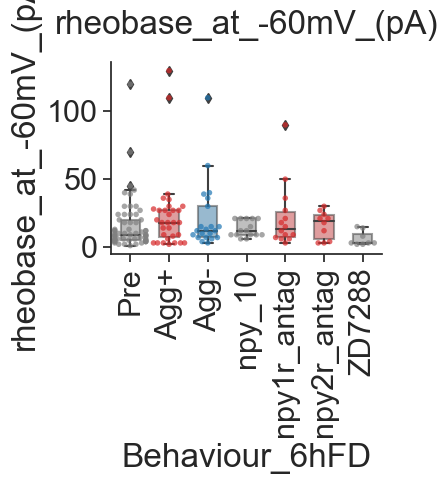

AHP_(mV) ('Pre', 'Agg+') 0.43839162689464706 0.7846979756790236 0.21919581344732353
AHP_(mV) ('Pre', 'Agg-') 0.682407498428275 0.6631372060515669 0.3412037492141375
AHP_(mV) ('Pre', 'npy1r_antag') 0.1042686796936504 0.9494572549034562 0.0521343398468252
AHP_(mV) ('Pre', 'npy2r_antag') 0.4415405624351012 0.7857909217571621 0.2207702812175506
AHP_(mV) ('Pre', 'npy_10') 0.9339974866580283 0.46699874332901414 0.5384855937507627
AHP_(mV) ('Pre', 'ZD7288') 0.9547027682916275 0.47735138414581374 0.5452242935443821
AHP_(mV) ('Agg+', 'Agg-') 0.5751721848393921 0.28758609241969607 0.7246156397441518
AHP_(mV) ('Agg+', 'npy1r_antag') 0.23182923128832922 0.89333531172307 0.11591461564416461
AHP_(mV) ('Agg+', 'npy2r_antag') 0.9689401457302569 0.5464957895692552 0.48447007286512844
AHP_(mV) ('Agg+', 'npy_10') 0.4190312130238445 0.20951560651192225 0.8028331128552073
AHP_(mV) ('Agg+', 'ZD7288') 0.5148719362740404 0.2574359681370202 0.8074015124322081
AHP_(mV) ('Agg-', 'npy1r_antag') 0.1327953964849448

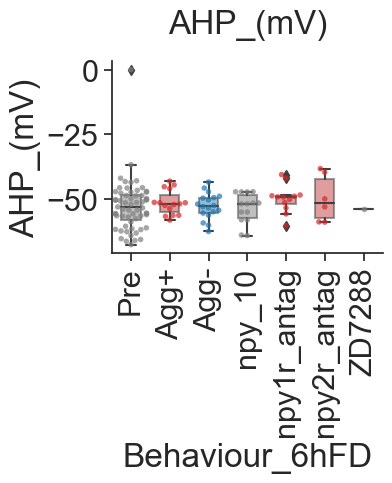

Vm ('Pre', 'Agg+') 0.7001860857748857 0.6517697587626763 0.35009304288744286
Vm ('Pre', 'Agg-') 0.5059726708502595 0.7490642455995589 0.25298633542512977
Vm ('Pre', 'npy1r_antag') 0.06155381242762307 0.9697753795675509 0.030776906213811534
Vm ('Pre', 'npy2r_antag') 0.8687269926970953 0.43436349634854765 0.5695750575428276
Vm ('Pre', 'npy_10') 0.44928219290153704 0.7777506969341503 0.22464109645076852
Vm ('Pre', 'ZD7288') 0.05696856621362753 0.972199929314612 0.028484283106813765
Vm ('Agg+', 'Agg-') 0.911084019139028 0.551262432827464 0.455542009569514
Vm ('Agg+', 'npy1r_antag') 0.26607738079943555 0.8716832830620593 0.13303869039971777
Vm ('Agg+', 'npy2r_antag') 0.9198537663906738 0.4599268831953369 0.5514659373100511
Vm ('Agg+', 'npy_10') 0.7895075436379628 0.6137843017866603 0.3947537718189814
Vm ('Agg+', 'ZD7288') 0.16777100640194242 0.9207382540805547 0.08388550320097121
Vm ('Agg-', 'npy1r_antag') 0.15927452165285128 0.9248468101477252 0.07963726082642564
Vm ('Agg-', 'npy2r_antag')

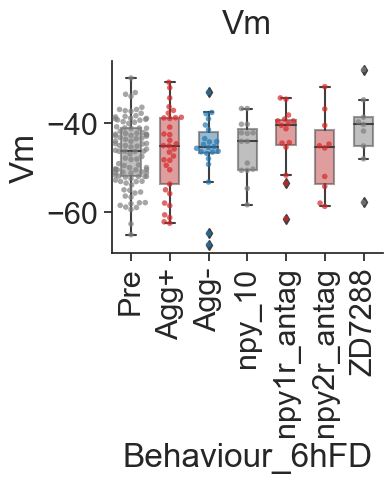

Input_Resistance ('Pre', 'Agg+') 0.00959484260193699 0.9952915165980222 0.004797421300968495
Input_Resistance ('Pre', 'Agg-') 0.7897476721570257 0.39487383607851284 0.608187310539246
Input_Resistance ('Pre', 'npy1r_antag') 0.20332306298223934 0.9000994549153645 0.10166153149111967
Input_Resistance ('Pre', 'npy2r_antag') 0.3971444938340719 0.8049059302114208 0.19857224691703595
Input_Resistance ('Pre', 'npy_10') 0.0018205584225745807 0.9991200631134345 0.0009102792112872903
Input_Resistance ('Pre', 'ZD7288') 0.0012071520714673186 0.9994239465295898 0.0006035760357336593
Input_Resistance ('Agg+', 'Agg-') 0.04608250364957072 0.02304125182478536 0.9779262603871585
Input_Resistance ('Agg+', 'npy1r_antag') 0.4121413951366578 0.2060706975683289 0.8005432826209113
Input_Resistance ('Agg+', 'npy2r_antag') 0.5139400328000707 0.25697001640003536 0.7527199055033553
Input_Resistance ('Agg+', 'npy_10') 0.3249635822878799 0.8432115466459411 0.16248179114393996
Input_Resistance ('Agg+', 'ZD7288') 0.10

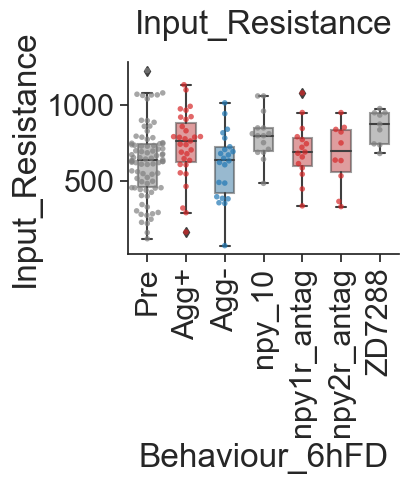

sPSC_frequency ('Pre', 'Agg+') 0.6299516553223251 0.31497582766116256 0.6891865742119738
sPSC_frequency ('Pre', 'Agg-') 0.16569340327720272 0.08284670163860136 0.9195722903891199
sPSC_frequency ('Pre', 'npy1r_antag') 0.007897739636139703 0.9962866884978105 0.003948869818069851
sPSC_frequency ('Pre', 'npy2r_antag') 0.03902562359917241 0.9817156900241657 0.019512811799586204
sPSC_frequency ('Pre', 'npy_10') 0.0860132039524211 0.9595241740034287 0.04300660197621055
sPSC_frequency ('Pre', 'ZD7288') 0.00012029387794381674 6.014693897190837e-05 0.9999500148468708
sPSC_frequency ('Agg+', 'Agg-') 0.4758363925692679 0.23791819628463395 0.7672413202136257
sPSC_frequency ('Agg+', 'npy1r_antag') 0.004334839305559387 0.9979760324616022 0.0021674196527796934
sPSC_frequency ('Agg+', 'npy2r_antag') 0.03447280362946219 0.9839235273682512 0.017236401814731094
sPSC_frequency ('Agg+', 'npy_10') 0.07085963754292053 0.9668384268926304 0.035429818771460266
sPSC_frequency ('Agg+', 'ZD7288') 0.0014364535876886

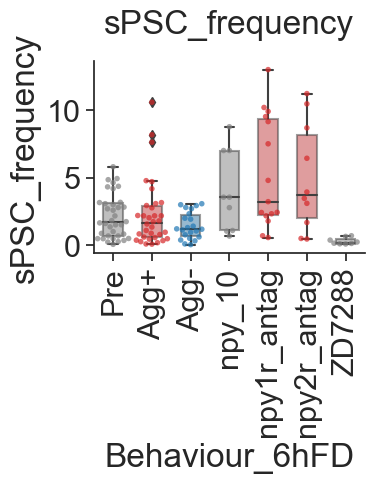

sPSC_Amplitude(pA) ('Pre', 'Agg+') 0.5687163130626809 0.28435815653134044 0.7196137518093411
sPSC_Amplitude(pA) ('Pre', 'Agg-') 0.025875307502539382 0.012937653751269691 0.9875872552184235
sPSC_Amplitude(pA) ('Pre', 'npy1r_antag') 0.5216038164206143 0.26080190821030713 0.745869695162643
sPSC_Amplitude(pA) ('Pre', 'npy2r_antag') 0.3651920681833466 0.8243702001063768 0.1825960340916733
sPSC_Amplitude(pA) ('Pre', 'npy_10') 0.8314555344756641 0.41572776723783206 0.5953050545108456
sPSC_Amplitude(pA) ('Pre', 'ZD7288') 0.002009908114278183 0.0010049540571390916 0.9990932720301338
sPSC_Amplitude(pA) ('Agg+', 'Agg-') 0.059016462042317176 0.029508231021158588 0.9716004435682077
sPSC_Amplitude(pA) ('Agg+', 'npy1r_antag') 0.7203917662706332 0.3601958831353166 0.6478893252259291
sPSC_Amplitude(pA) ('Agg+', 'npy2r_antag') 0.2809375228491704 0.8656846198600806 0.1404687614245852
sPSC_Amplitude(pA) ('Agg+', 'npy_10') 0.8931110395377335 0.5652243268076464 0.44655551976886676
sPSC_Amplitude(pA) ('Agg+'

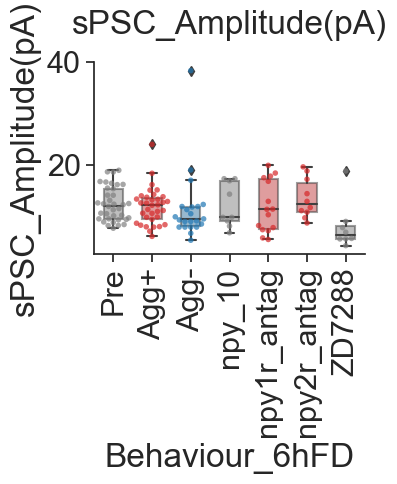

sPSCs_Rise time ('Pre', 'Agg+') 0.5523105533089088 0.7280566565646827 0.2761552766544544
sPSCs_Rise time ('Pre', 'Agg-') 0.3970241676687203 0.19851208383436014 0.8062699201116964
sPSCs_Rise time ('Pre', 'npy1r_antag') 0.9820976399517795 0.4910488199758897 0.517897854308699
sPSCs_Rise time ('Pre', 'npy2r_antag') 0.9768442965316141 0.48842214826580704 0.5231459541923411
sPSCs_Rise time ('Pre', 'npy_10') 0.6762317557648871 0.6731199873706264 0.33811587788244357
sPSCs_Rise time ('Pre', 'ZD7288') 0.5400376799085684 0.7408208026759457 0.2700188399542842
sPSCs_Rise time ('Agg+', 'Agg-') 0.24122416689162263 0.12061208344581131 0.8827397904455776
sPSCs_Rise time ('Agg+', 'npy1r_antag') 0.7596540919314303 0.37982704596571515 0.6284638541825605
sPSCs_Rise time ('Agg+', 'npy2r_antag') 0.7995867474237126 0.3997933737118563 0.6110631611022975
sPSCs_Rise time ('Agg+', 'npy_10') 1.0 0.50600050917747 0.50600050917747
sPSCs_Rise time ('Agg+', 'ZD7288') 0.7597296065659777 0.6323293831535004 0.37986480328

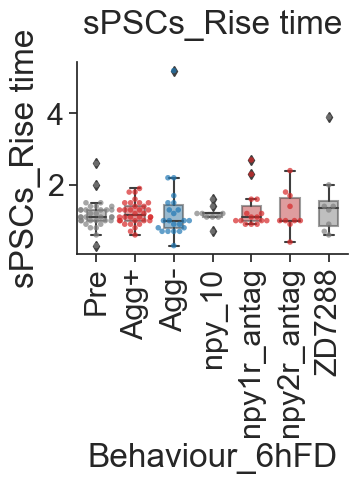

sPSCs (decay) ('Pre', 'Agg+') 0.445197370104469 0.7812073251799863 0.2225986850522345
sPSCs (decay) ('Pre', 'Agg-') 0.5852881642217079 0.7135773222548022 0.29264408211085396
sPSCs (decay) ('Pre', 'npy1r_antag') 0.18937115235964863 0.9091054715349195 0.09468557617982432
sPSCs (decay) ('Pre', 'npy2r_antag') 0.29435613580791864 0.8595169674272871 0.14717806790395932
sPSCs (decay) ('Pre', 'npy_10') 0.08583563248185513 0.9598808560774906 0.04291781624092757
sPSCs (decay) ('Pre', 'ZD7288') 0.33514868886616145 0.16757434443308072 0.8407663319762118
sPSCs (decay) ('Agg+', 'Agg-') 0.9861774126895494 0.4930887063447747 0.5138205132313249
sPSCs (decay) ('Agg+', 'npy1r_antag') 0.43482039170687026 0.788915277174296 0.21741019585343513
sPSCs (decay) ('Agg+', 'npy2r_antag') 0.6240645324651697 0.6978070165298174 0.31203226623258484
sPSCs (decay) ('Agg+', 'npy_10') 0.3171835069285409 0.8485234065687591 0.15859175346427046
sPSCs (decay) ('Agg+', 'ZD7288') 0.3042033696719191 0.15210168483595954 0.8553235

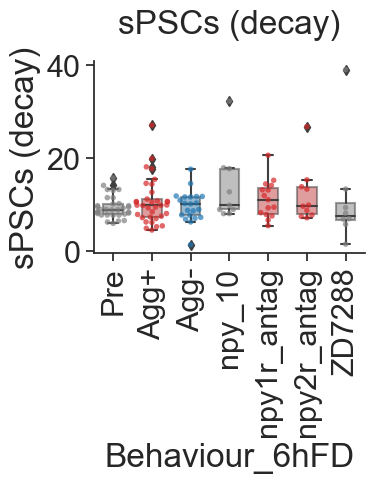

In [10]:
filter_cat = ['Pre', 'Agg+', 'Agg-', 'npy_10', 'npy1r_antag', 'npy2r_antag' ,'ZD7288']

# set categorical variables
ephys['Behaviour_6hFD'] = pd.Categorical(ephys['Behaviour_6hFD'], categories=filter_cat, ordered=True)


preprocess_plot(ephys[ephys.Behaviour_6hFD.isin(filter_cat)],'Behaviour_6hFD', 'pan', 
                palette=['Gray', 'Tab:red', 'Tab:Blue', 'Gray', 'Tab:red', 'Tab:red', 'Gray'], order = filter_cat,
                  plotting= True)


Cm(pF) ('yes', 'no') 0.7301587301587302 0.7222222222222223 0.3650793650793651
Gal_positive
no     48.160853
yes    43.144010
Name: Cm(pF), dtype: float64


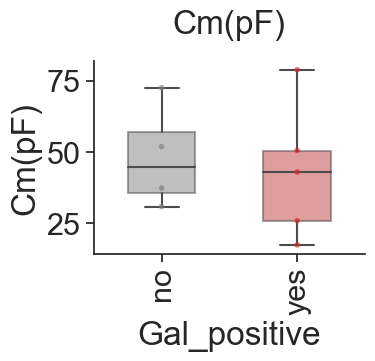

Firing_freq_(Hz)_I0 ('yes', 'no') 1.0 0.537537802412245 0.537537802412245
Gal_positive
no     2.565
yes    0.740
Name: Firing_freq_(Hz)_I0, dtype: float64


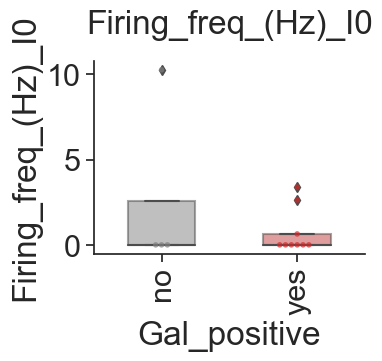

Instant_freq_(Hz) ('yes', 'no') 1.0 0.537537802412245 0.537537802412245
Gal_positive
no     2.600000
yes    0.871111
Name: Instant_freq_(Hz), dtype: float64


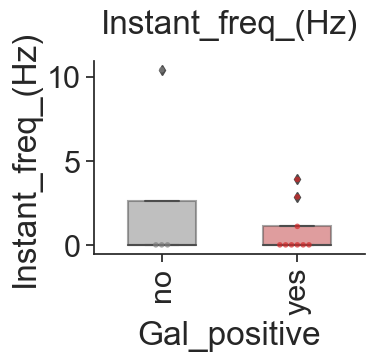

isi_(ms) ('yes', 'no') 0.5 0.25 1.0
Gal_positive
no      97.420000
yes    740.333333
Name: isi_(ms), dtype: float64


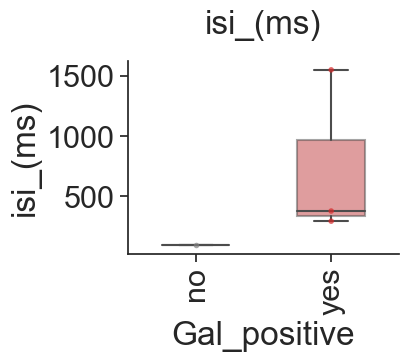

CaT ('yes', 'no') 0.5842375964997912 0.7781879160849756 0.2921187982498956
Gal_positive
no     8.507500
yes    1.842857
Name: CaT, dtype: float64


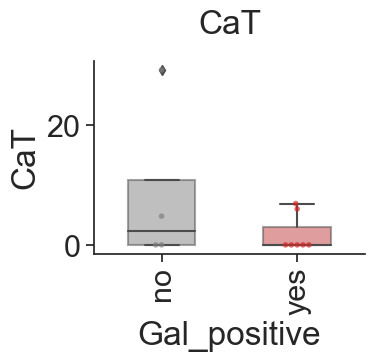

Ih_at_-120mV ('yes', 'no') 0.5376384478605154 0.7859650844246839 0.2688192239302577
Gal_positive
no     3.28750
yes    4.52875
Name: Ih_at_-120mV, dtype: float64


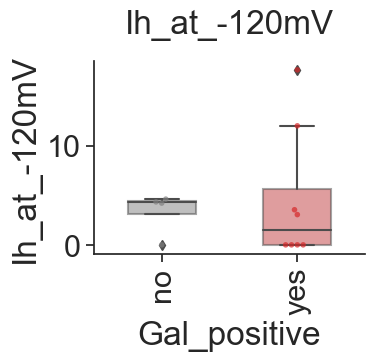

AP_ampl ('yes', 'no') 0.5 1.0 0.25
Gal_positive
no     98.400000
yes    70.266667
Name: AP_ampl, dtype: float64


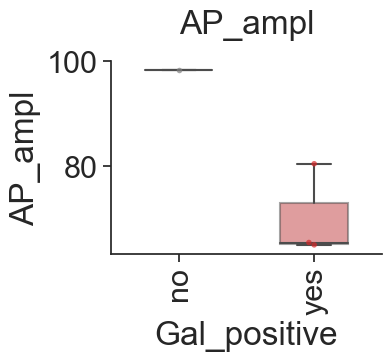

AP_halfwidth ('yes', 'no') 0.5 0.25 1.0
Gal_positive
no     1.710000
yes    3.613333
Name: AP_halfwidth, dtype: float64


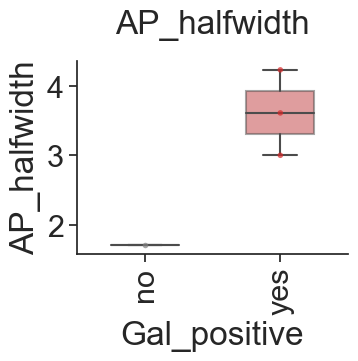

AP_time_to_peak ('yes', 'no') 0.5 0.25 1.0
Gal_positive
no     0.620000
yes    2.026667
Name: AP_time_to_peak, dtype: float64


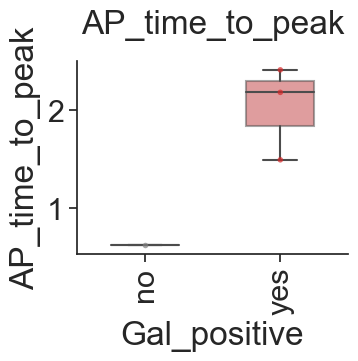

area(mV_ms) ('yes', 'no') 0.5 0.25 1.0
Gal_positive
no     132.000000
yes    240.766667
Name: area(mV_ms), dtype: float64


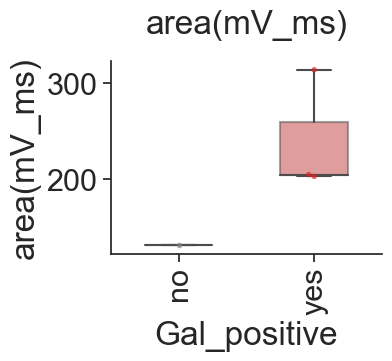

rheobase_at_-60mV_(pA) ('yes', 'no') 0.9309874465595671 0.6024939140178809 0.46549372327978356
Gal_positive
no     39.5
yes    20.5
Name: rheobase_at_-60mV_(pA), dtype: float64


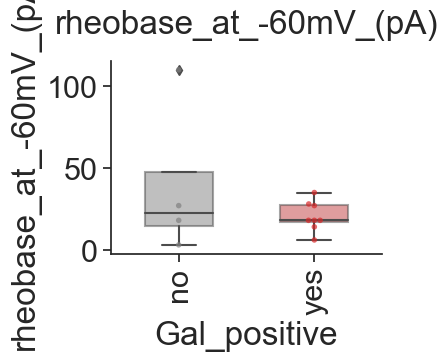

AHP_(mV) ('yes', 'no') 0.5 0.25 1.0
Gal_positive
no    -53.700000
yes   -44.816667
Name: AHP_(mV), dtype: float64


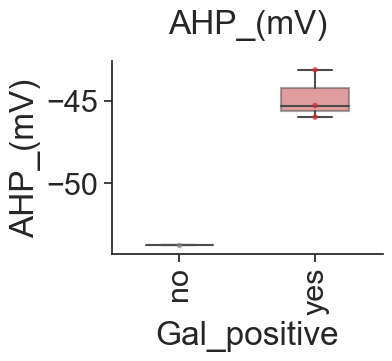

Vm ('yes', 'no') 0.005594405594405594 0.002797202797202797 0.9986013986013985
Gal_positive
no    -54.158175
yes   -39.845540
Name: Vm, dtype: float64


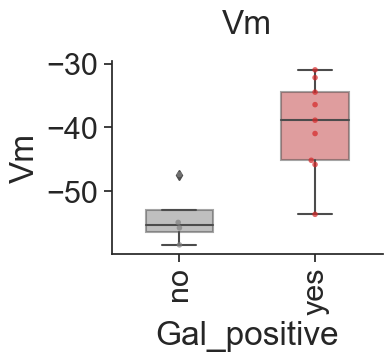

Input_Resistance ('yes', 'no') 0.6828282828282828 0.7151515151515151 0.3414141414141414
Gal_positive
no     672.011750
yes    680.159409
Name: Input_Resistance, dtype: float64


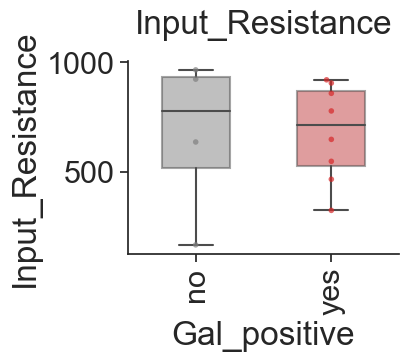

sPSC_frequency ('yes', 'no') 0.6041958041958042 0.3020979020979021 0.7482517482517482
Gal_positive
no     1.634487
yes    2.964686
Name: sPSC_frequency, dtype: float64


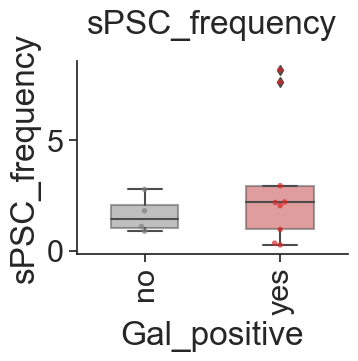

sPSC_Amplitude(pA) ('yes', 'no') 0.5034965034965035 0.793006993006993 0.2517482517482518
Gal_positive
no     11.982500
yes    10.981111
Name: sPSC_Amplitude(pA), dtype: float64


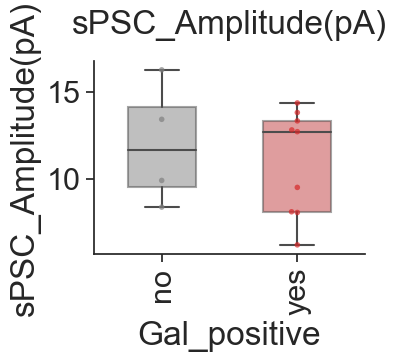

sPSCs_Rise time ('yes', 'no') 0.8139237277305011 0.6525738487519237 0.4069618638652506
Gal_positive
no     1.275000
yes    1.188889
Name: sPSCs_Rise time, dtype: float64


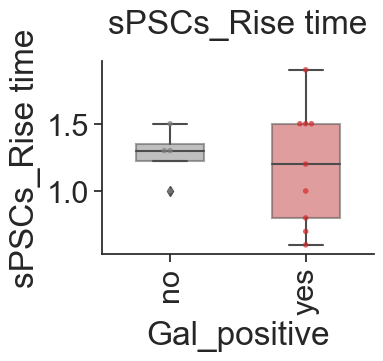

sPSCs (decay) ('yes', 'no') 0.1986013986013986 0.0993006993006993 0.9258741258741259
Gal_positive
no      8.942500
yes    12.294444
Name: sPSCs (decay), dtype: float64


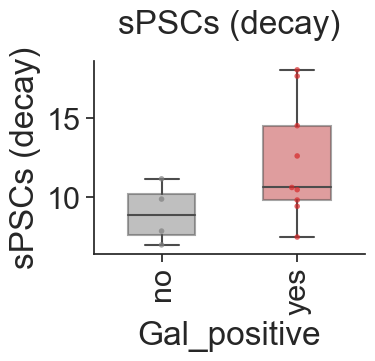

In [26]:
preprocess_plot(ephys[(ephys.Gal_positive.isin(['no', 'yes'])) & (ephys.Behaviour_6hFD.isin(['Agg-', 'Agg+']))], 
                'Gal_positive', 'gal', palette=['Gray', 'Tab:red'], order = ['no', 'yes'], plotting= True)


In [12]:
preprocess_plot(no_gal,'gal_minus')

TypeError: preprocess_plot() missing 3 required positional arguments: 'name', 'palette', and 'order'

Cm(pF) 0.7323693239926063


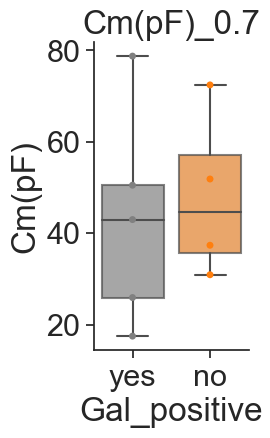

Firing_freq_(Hz)_I0 0.6407646405225094


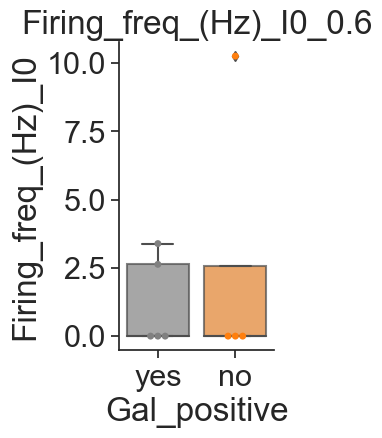

Instant_freq_(Hz) 0.6729139443059836


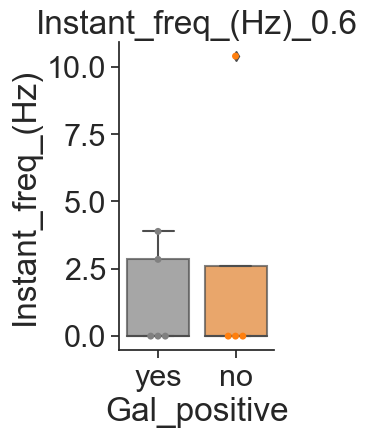

isi_(ms) 0.264690461240659


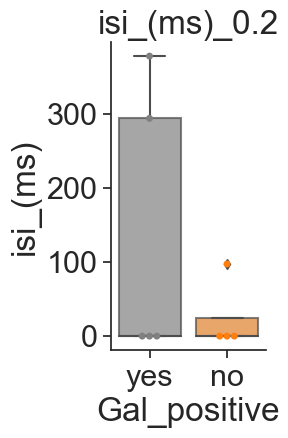

CaT 0.3112911367063223


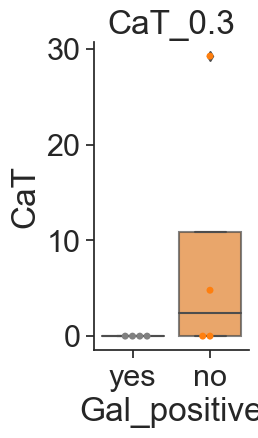

Ih_at_-120mV 0.8027274535869496


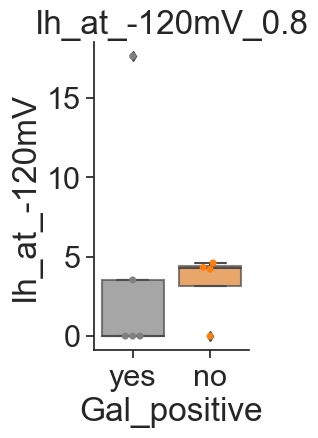

AP_ampl 0.8859255231987084


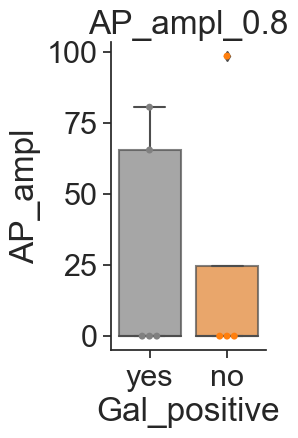

AP_halfwidth 0.32548590700011526


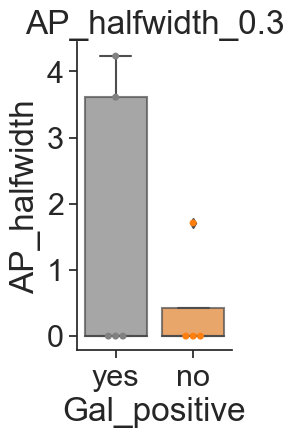

AP_time_to_peak 0.2899382771639767


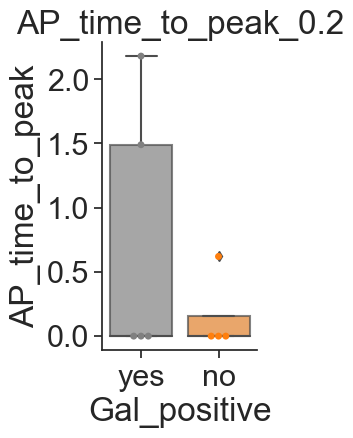

area(mV_ms) 0.37498685458791303


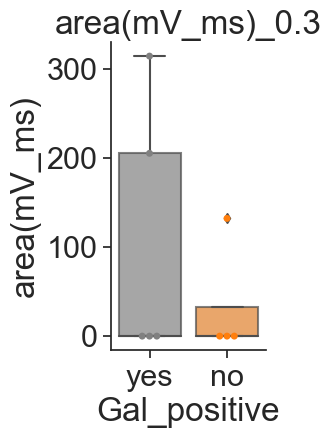

rheobase_at_-60mV_(pA) 0.4161053280322605


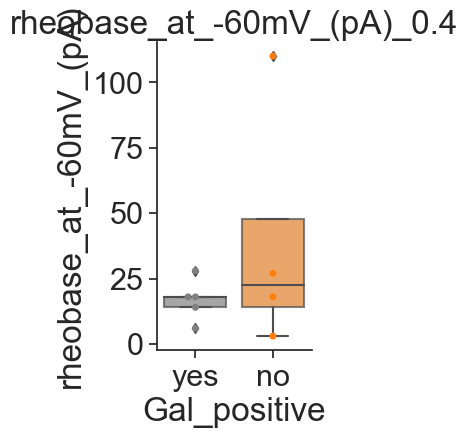

AHP_(mV) 0.80731274924489


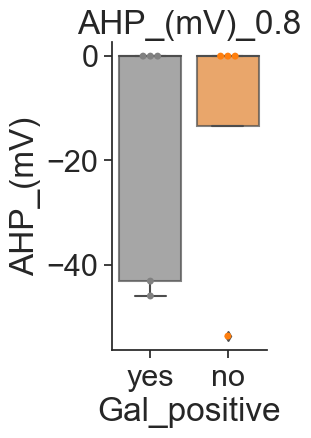

Vm 0.029015379302906888


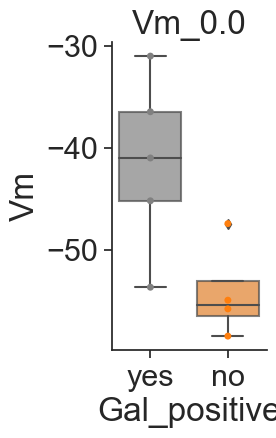

Input_Resistance 0.5478892229399508


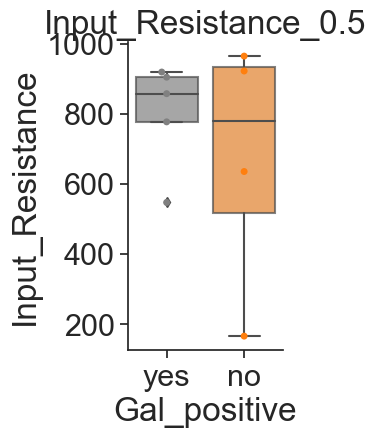

sPSC_frequency 0.2622481192712615


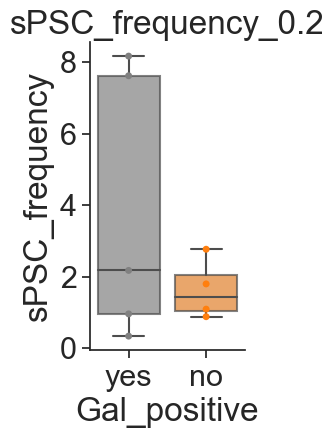

sPSC_Amplitude(pA) 0.8336416545013177


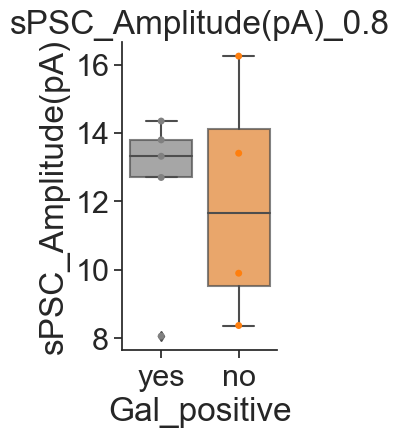

sPSCs_Rise time 0.1506195618276333


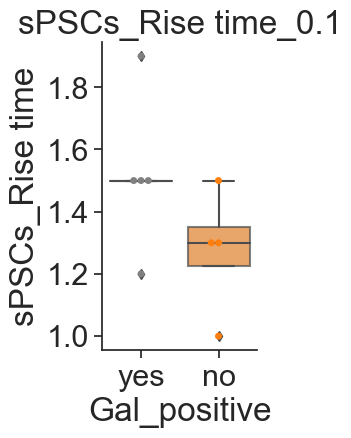

sPSCs (decay) 0.1946103198988765


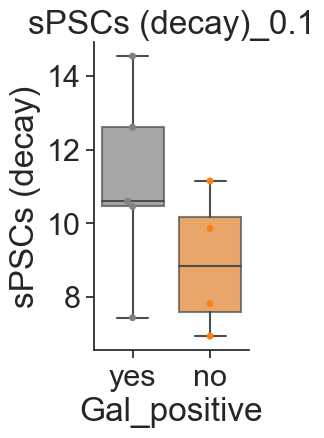

AC-I0 nan
AC_-60 nan


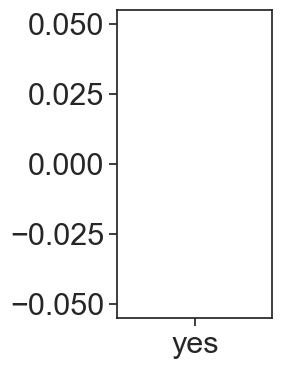

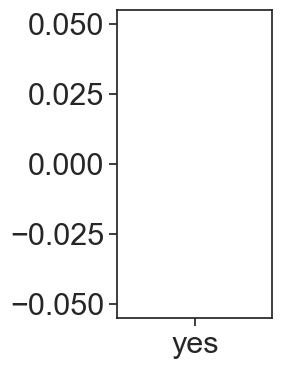

In [ ]:
gals = pd.concat([gal,no_gal], axis = 0)
gals = gals[gals.Behaviour_6hFD.isin(['Agg+', 'Agg-'])]

ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
   'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)', 'AC-I0', 'AC_-60']

for column in ls:
    try:
        _, p = stats.ttest_ind(gals[(gals.Gal_positive == 'yes')][column].dropna(),
                                    gals[(gals.Gal_positive == 'no')][column].dropna(),
                                    equal_var = False)
        print(column , p)


        gals[column] = pd.to_numeric(gals[column])
        fig,ax = plt.subplots(figsize = (2,4))
        sns.swarmplot(x='Gal_positive', y =column, data= gals, palette = ['gray', 'Tab:orange'])
        sns.boxplot(x='Gal_positive', y =column, data= gals, palette = ['gray', 'Tab:orange'], boxprops=dict(alpha=0.7))
        sns.despine()
        plt.title(column + '_' + str(p)[:3])
        plt.savefig(f'output_figures/gal_nogal_{column}.png',dpi = 300, bbox_inches = 'tight')
        plt.show()
    except Exception:
        continue

In [17]:
trial = ephys[ephys.Behaviour_6hFD.isin(['Pre', 'Agg-', 'Agg+'])]
trial = trial.rename(columns={'Ih_at_-120mV': 'ih_current', 
                              'Firing_freq_(Hz)_I0': 'firing_freq', 
                              'sPSC_Amplitude(pA)': 'sPSC_Amplitude'})
model = smf.ols('Input_Resistance ~  ih_current  ', data=trial).fit()
#model.summary()
sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
ih_current,1.072356e+06,1.0,21.100988,0.000007
Residual,1.240013e+07,244.0,NaN,NaN


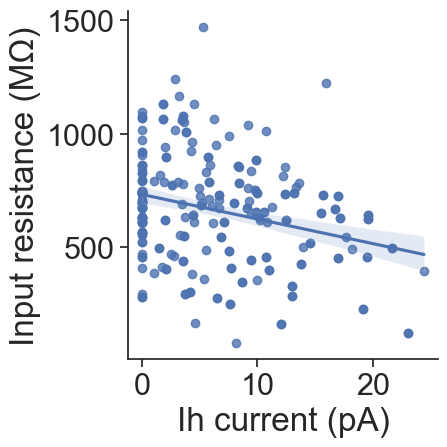

In [19]:
sns.lmplot(x = 'ih_current', y = 'Input_Resistance', data = trial, palette = ['darkgray', '#F97306', 'blue'])
plt.xlabel('Ih current (pA)')
plt.ylabel('Input resistance (MΩ)')
plt.savefig(f'output_figures/ih_input_resistance.png',dpi = 300, bbox_inches = 'tight')
          


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


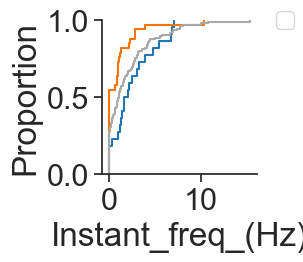

In [33]:
l = 'Instant_freq_(Hz)'
max = ephys[l].max()
cs = ['darkgray', '#F97306', 'Tab:blue']
conds = ['Pre', 'Agg+', 'Agg-']
fig, ax = plt.subplots(figsize=(2, 2))
sns.ecdfplot(data=ephys[ephys.Behaviour_6hFD.isin(conds)], x=l, hue="Behaviour_6hFD", palette = cs, ax = ax)
sns.despine()
plt.legend(loc='center left', bbox_to_anchor=(1.05, 1), fontsize = 16)

plt.savefig(f'output_figures/ECDF_{l}.png',dpi = 300, bbox_inches = 'tight')
plt.show()

    

## silent prop

I_zero          phasic  silent  tonic  All
Behaviour_6hFD                            
Agg+                 7      18      8   33
Agg-                 4       4     14   22
Pre                 19      28     58  105
ZD7288               0       8      1    9
npy1r_antag          2       3     10   15
npy2r_antag          3       4      3   10
npy_10               2       1     12   15
All                 37      66    106  209
0.00028214043379248577


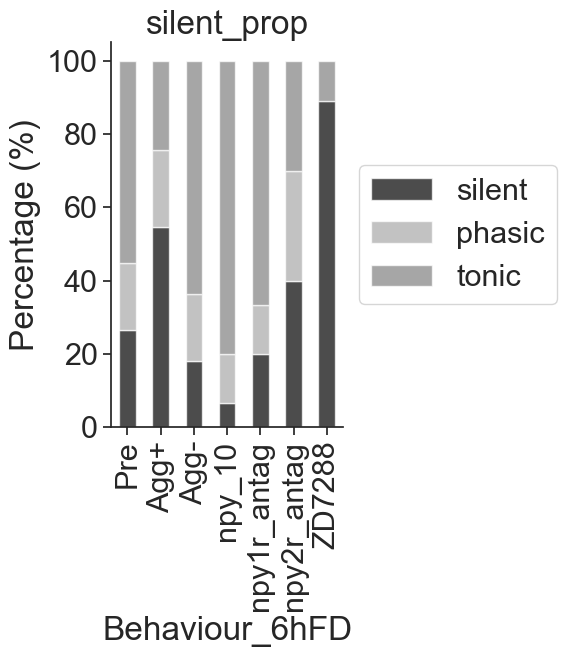

In [28]:
## silent proportion
cols = ['silent', 'phasic', 'tonic']
cat = ['Pre', 'Agg+', 'Agg-', 'npy_10', 'npy1r_antag', 'npy2r_antag', 'ZD7288']
silent_prop = proportion(ephys[ephys.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'I_zero', cols)
silent_prop['Behaviour_6hFD'] = pd.Categorical(silent_prop['Behaviour_6hFD'], cat)
silent_prop = silent_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(silent_prop, 'Behaviour_6hFD')
plt.xticks(rotation = 90)
plt.title('silent_prop')
plt.savefig('output_figures/silent_prop.png',dpi = 300, bbox_inches = 'tight')

In [28]:
cols = ['silent', 'tonic']
silent_prop = proportion(gals, 'Gal_positive', 'I_zero', cols)
silent_prop['Gal_positive'] = pd.Categorical(silent_prop['Gal_positive'], ['yes', 'no'])
silent_prop = silent_prop.sort_values(by = ['Gal_positive'])
prop_plot(silent_prop, 'Gal_positive')
plt.title('galanin_silent_prop')
plt.savefig('output_figures/galanin_silent_prop.png',dpi = 300, bbox_inches = 'tight')

NameError: name 'gals' is not defined

## adaptive prop

Adaptive        ?  no  yes  All
Behaviour_6hFD                 
Pre             1  15   27   43
Agg+            1  12   16   29
Agg-            0  18    3   21
All             2  45   46   93
0.0035491449670240205


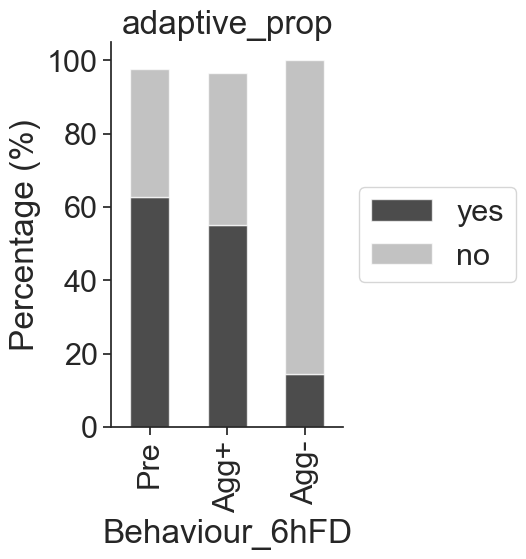

In [29]:
## adaptive proportion
cols = ['yes', 'no']
cat = ['Pre', 'Agg+', 'Agg-']
ad_prop = proportion(ephys[ephys.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'Adaptive', cols)
ad_prop['Behaviour_6hFD'] = pd.Categorical(ad_prop['Behaviour_6hFD'], cat)
ad_prop = ad_prop.sort_values(by = ['Behaviour_6hFD'])

prop_plot(ad_prop, 'Behaviour_6hFD')
plt.xticks(rotation = 90)
plt.title('adaptive_prop')
plt.savefig('output_figures/adaptive_prop.png',dpi = 300, bbox_inches = 'tight')

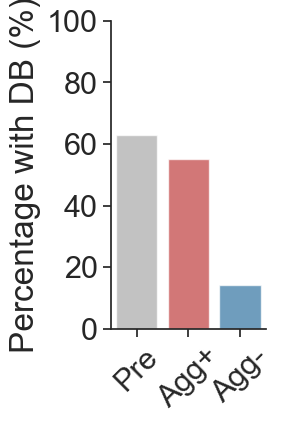

In [38]:
plt.subplots(figsize = (2,4))
sns.barplot(x = 'Behaviour_6hFD', y = 'yes',data = ad_prop, palette= ['darkgray', 'Tab:red', 'Tab:blue'], alpha = 0.7)
plt.xticks(rotation = 45)
plt.ylim([0,100])
plt.ylabel('Percentage with DB (%)')
plt.xlabel('')
sns.despine()
plt.savefig('output_figures/adaptive_prop.png',dpi = 300, bbox_inches = 'tight')

In [77]:
cols = ['yes', 'no']
ad_prop = proportion(gals, 'Gal_positive', 'Adaptive', cols)
ad_prop['Gal_positive'] = pd.Categorical(ad_prop['Gal_positive'], ['yes', 'no'])
ad_prop = ad_prop.sort_values(by = ['Gal_positive'])
prop_plot(ad_prop, 'Gal_positive')
plt.title('galanin_adaptive_prop')
plt.savefig('output_figures/galanin_adaptive_prop.png',dpi = 300, bbox_inches = 'tight')

NameError: name 'gals' is not defined

## calcium T prop

cat_categ         no  no   yes  yes   All
Behaviour_6hFD                           
Agg+              20    0    8     0   28
Agg-               9    1   11     1   22
Pre               51    0   31     0   82
ZD7288             6    0    3     0    9
ZD7288_20          2    0    1     0    3
agrp_100           7    0    0     0    7
agrp_100_paired    6    0    1     0    7
npy_10             3    1    0     0    4
npy_100            4    0    0     0    4
npy_antag         14    0    1     0   15
All              122    2   56     1  181
0.004202880379034892


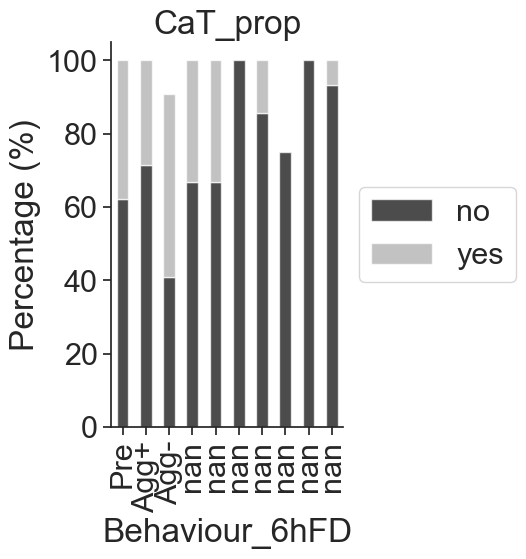

In [114]:
## calcium T proportion
cols = ['no', 'yes']
ca_prop = proportion(ephys, 'Behaviour_6hFD', 'cat_categ', cols)
ca_prop['Behaviour_6hFD'] = pd.Categorical(ca_prop['Behaviour_6hFD'],cat)
ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ca_prop, 'Behaviour_6hFD')
plt.xticks(rotation = 90)

plt.title('CaT_prop')
plt.savefig('output_figures/CaT_prop.png',dpi = 300, bbox_inches = 'tight')

In [79]:
cols = ['yes', 'no']
ca_prop = proportion(gals, 'Gal_positive', 'cat_categ', cols)
ca_prop['Gal_positive'] = pd.Categorical(ca_prop['Gal_positive'], ['yes', 'no'])
ca_prop = ca_prop.sort_values(by = ['Gal_positive'])
prop_plot(ca_prop, 'Gal_positive')

plt.title('galanin_CaT_prop')
plt.savefig('output_figures/galanin_CaT_prop.png',dpi = 300, bbox_inches = 'tight')

NameError: name 'gals' is not defined

## IH prop

IH               no  yes  All
Behaviour_6hFD               
Agg+             11   17   28
Agg-              1   21   22
Pre              24   58   82
ZD7288            9    0    9
ZD7288_20         3    0    3
agrp_100          5    2    7
agrp_100_paired   1    6    7
npy_10            3    1    4
npy_100           4    0    4
npy_100_paired    2    1    3
npy_10_paired     0    5    5
npy_antag         3   12   15
All              66  123  189
1.2495740282987222e-07


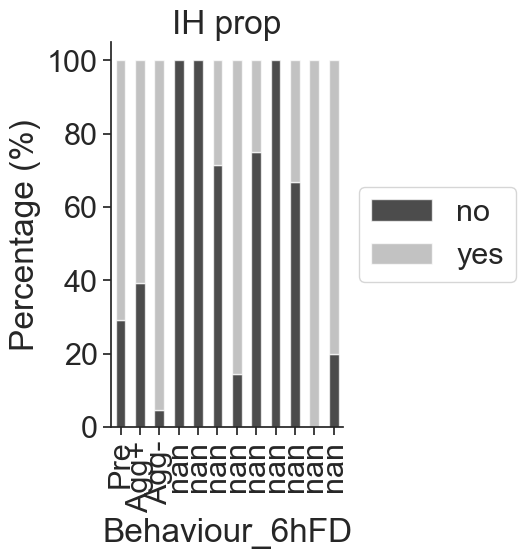

In [116]:
ephys.loc[(ephys['Ih_at_-120mV'] == 0), 'IH']  = 'no'
ephys.loc[(ephys['Ih_at_-120mV'] >0 ), 'IH']  = 'yes'
cols = ['no', 'yes']

ca_prop = proportion(ephys, 'Behaviour_6hFD', 'IH', cols)
ca_prop['Behaviour_6hFD'] = pd.Categorical(ca_prop['Behaviour_6hFD'], cat)
ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ca_prop, 'Behaviour_6hFD')

plt.title('IH prop')
plt.xticks(rotation = 90)
plt.savefig('output_figures/IH_prop.png',dpi = 300, bbox_inches = 'tight')

IH                   no  yes  All
I_zero_reclassified              
phasic                7   25   32
silent               31   39   70
tonic                26   59   85
All                  64  123  187
0.05461411697391892


Text(0.5, 0, '')

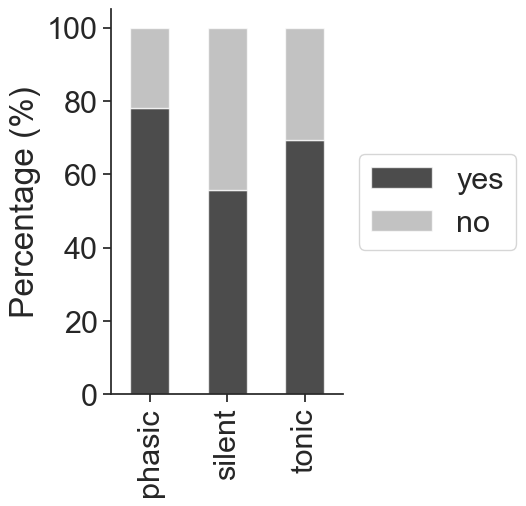

In [117]:
cols = ['yes', 'no']
ih_prop =  proportion(ephys, 'I_zero_reclassified', 'IH', cols)
# ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ih_prop, 'I_zero_reclassified')
plt.xticks(rotation = 90)
plt.xlabel('')

# ramp analysis

In [ ]:
df = pd.read_csv('ramps_all.csv')
ephys = pd.read_csv('sampled_ephys_data.csv')
ephys.rename(columns = {'Instant_freq_(Hz)_1/ISI':'Instant_freq_(Hz)', 
                        'experiment_day':'filename'}, inplace =True)

df.rename(columns = {'I_Injected(pA)': 'Injected'}, inplace = True)
df = pd.merge(df, ephys, on = 'filename')

df['Injected'] = pd.Categorical(df['Injected'], df['Injected'].unique()[:-2]).as_ordered()

start = df['Ramp_start'][0]
num_spike = df.groupby(by = ['filename', 'Injected']).size().reset_index(name ='num_spike')
df = df.groupby(['filename', 'Injected'], dropna = False).first().reset_index().drop_duplicates()

df.loc[df['Event start '] == 0,'Event start '] = 2080
df['latency'] = df['Event start ']- start
df['num_spike'] = num_spike.num_spike
df =  pd.merge(df, ephys, on = ['filename', 'Behaviour_6hFD'])



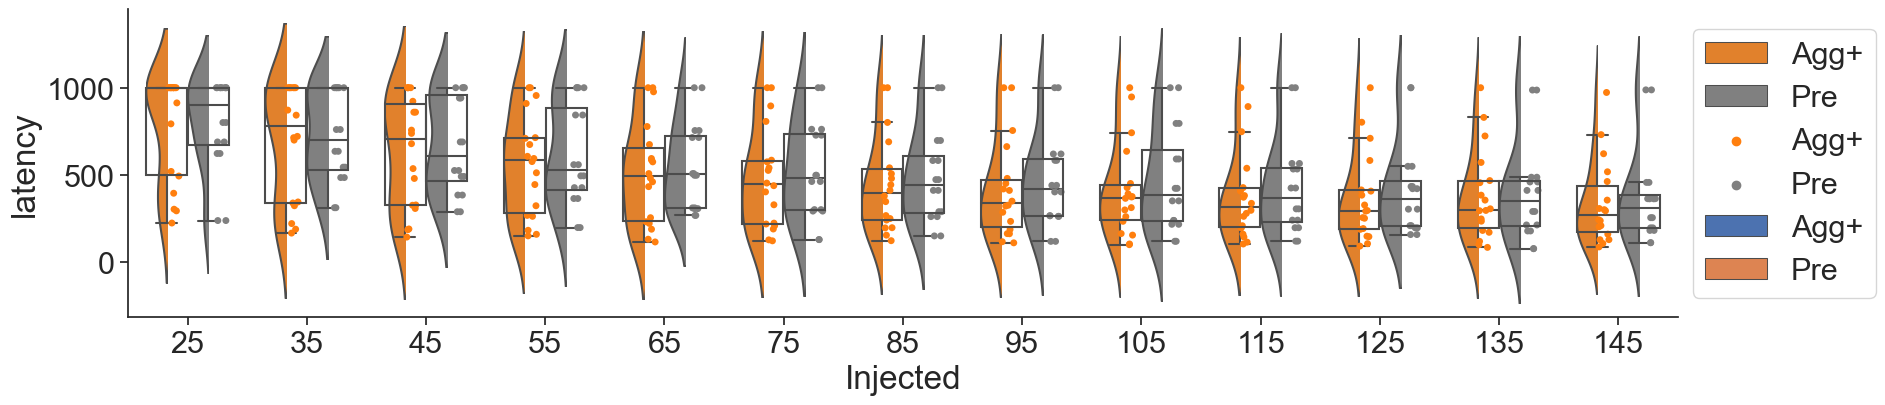

In [ ]:
prop = 'latency'

fig = plt.subplots(figsize = [20,4])

palette = ['Tab:orange', 'gray']
ax = sns.violinplot(x ='Injected', y = prop, hue = 'Behaviour_6hFD', 
                    dodge = True, data = df,
                    palette=palette,width = 0.7,
                    scale="width", inner=None)

# ax = sns.lmplot(x ='Injected', y = prop, hue = 'Behaviour_6hFD', data = df)
xlim = ax.get_xlim()
ylim = ax.get_ylim()
for violin in ax.collections:
    bbox = violin.get_paths()[0].get_extents()
    x0, y0, width, height = bbox.bounds
    violin.set_clip_path(plt.Rectangle((x0, y0), width / 2, height, transform=ax.transData))

old_len_collections = len(ax.collections)
sns.stripplot(x  = 'Injected', y = prop, hue = 'Behaviour_6hFD',
               dodge = True, data = df, palette=palette, ax=ax)

sns.boxplot(x  = 'Injected', y = prop, hue = 'Behaviour_6hFD',
                data = df, saturation=1, showfliers=False,
            width=0.7, boxprops={'zorder': 3, 'facecolor': 'none'}, ax=ax)


for dots in ax.collections[old_len_collections:]:
    dots.set_offsets(dots.get_offsets() + np.array([.08, 0]))
    
ax.set_xlim(xlim)
ax.set_ylim(ylim)

sns.despine()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

In [ ]:
model = smf.ols('latency ~ C(Injected) * C(Behaviour_6hFD)', data=df).fit()
#model.summary()
sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
C(Injected),7.381683e+06,12.0,8.054835,1.237526e-13
C(Behaviour_6hFD),1.470714e+05,1.0,1.925798,1.659617e-01
C(Injected):C(Behaviour_6hFD),1.909296e+04,12.0,0.020834,1.000000e+00
Residual,3.176953e+07,416.0,NaN,NaN


In [ ]:
df['combination'] = df.Injected.astype(str) + " / " + df.Behaviour_6hFD
m_comp = pairwise_tukeyhsd(endog=df['latency'], groups=df['combination'], alpha=0.05)
m_comp._results_table

group1,group2,meandiff,p-adj,lower,upper,reject
105 / Agg+,105 / no_FD,53.6741,1.0,-402.1284,509.4766,False
105 / Agg+,115 / Agg+,-24.5592,1.0,-389.2012,340.0828,False
105 / Agg+,115 / no_FD,10.2366,1.0,-445.5659,466.0391,False
105 / Agg+,125 / Agg+,-40.0064,1.0,-404.6483,324.6356,False
105 / Agg+,125 / no_FD,-4.3258,1.0,-460.1283,451.4766,False
105 / Agg+,135 / Agg+,-25.7058,1.0,-390.3478,338.9361,False
105 / Agg+,135 / no_FD,-25.2135,1.0,-481.016,430.5889,False
105 / Agg+,145 / Agg+,-68.4944,1.0,-433.1364,296.1476,False
105 / Agg+,145 / no_FD,-48.6384,1.0,-504.4409,407.1641,False
105 / Agg+,25 / Agg+,359.0997,0.0598,-5.5423,723.7417,False


# estrous cycle influence

I_zero             phasic  silent  tonic  All
estrous_stage                                
?                       1       1      2    4
D                       5       7     16   28
E                       2       3      3    8
M                       3       7     14   24
P                       6       6     12   24
VS to be stained        0       0      1    1
no VS                   1       2      9   12
not taken               1       2      1    4
All                    19      28     58  105
0.9417552913501139
Empty DataFrame
Columns: []
Index: []


ValueError: No data; `observed` has size 0.

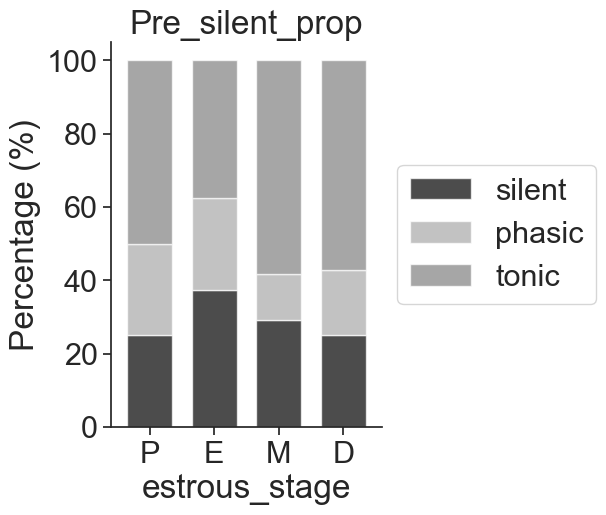

In [32]:
# silent proportion
ephys = pd.read_csv('sampled_ephys_data.csv')

ephys = ephys[ephys.I_zero.isin(['silent', 'phasic', 'tonic'])]
ephys.loc[(ephys['estrous_stage'] == 'P to E'), 'estrous_stage']  = 'P'
ephys.loc[(ephys['estrous_stage'] == 'D to P'), 'estrous_stage']  = 'D'
cols = ['silent', 'phasic', 'tonic']
# ephys.loc[ephys.Behaviour_6hFD.isin(['Agg+']),'Behaviour_6hFD'] = 'Post'

for state in ['Pre', 'Post']:
    state_df = ephys[ephys.Behaviour_6hFD == state]
    silent_prop = proportion(state_df, 'estrous_stage', 'I_zero', cols)
    silent_prop['estrous_stage'] = pd.Categorical(silent_prop['estrous_stage'], ['P', 'E', 'M', 'D'])
    silent_prop = silent_prop.sort_values(by = ['estrous_stage'])
    silent_prop = silent_prop[silent_prop.estrous_stage.isin(['P', 'E', 'M', 'D'])]
    


    silent_prop.plot(x = 'estrous_stage', 
            kind = 'bar', 
            stacked = True,  
            mark_right = False,
            color = ['black', 'darkgray','gray'],
            figsize = (3.5,5), alpha = 0.7, width = 0.7)
 
        
    plt.xticks(rotation = 0)
    ax = plt.gca()
    plt.ylabel('Percentage (%)')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    plt.title(f'{state}_silent_prop')
    plt.savefig(f'output_figures/{state}_silent_prop.png',dpi = 300, bbox_inches = 'tight')

-0.5709724581245322 0.42902754187546777


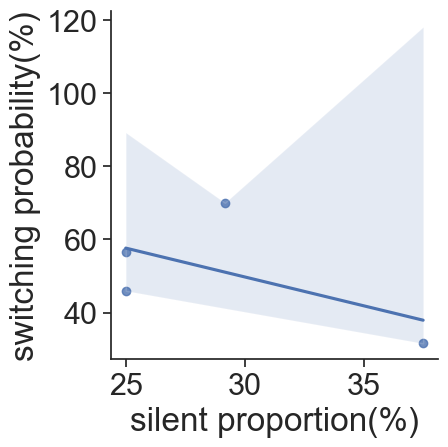

In [33]:
import scipy as sp
estrous_df = pd.read_csv('../NPS_behaviour_analysis/generated_datasets/estrous_data.csv')
estrous_df.rename(columns = {'Unnamed: 0':'estrous_stage', '0':'switching probability'}, inplace = True)
corr = pd.merge(silent_prop, estrous_df, on = 'estrous_stage')

r, p = sp.stats.pearsonr(corr['switching probability'], corr['silent'])
print(r, p)
sns.lmplot(x = 'silent', y = 'switching probability', data = corr)
plt.xlabel('silent proportion(%)')
plt.ylabel('switching probability(%)')
plt.savefig('output_figures/silent_switching_corr.png', dpi = 300, bbox_inches = 'tight')

In [25]:
state_df.estrous_stage.unique()

['D', NaN, 'E', 'M']
Categories (4, object): ['P', 'E', 'M', 'D']

Ih_at_-120mV 0.007966271039400048


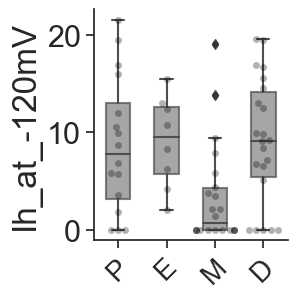

In [28]:
# IH current
ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)', 'AC-I0', 'AC_-60']

# ls = ['Ih_at_-120mV']

for state in ['Pre']:
    for column in ls:
        state_df = ephys.copy()
        state_df['estrous_stage'] = pd.Categorical(state_df['estrous_stage'], ['P', 'E', 'M', 'D'])
        state_df = state_df[state_df.Behaviour_6hFD == state]
        
        
        try:

            _, p = stats.f_oneway(state_df[column][state_df['estrous_stage'] == 'P'].dropna(),
                                    state_df[column][state_df['estrous_stage'] == 'E'].dropna(),
                                    state_df[column][state_df['estrous_stage'] == 'M'].dropna(),
                                    state_df[column][state_df['estrous_stage'] == 'D'].dropna())
        
            

            
            if p < 0.05:
                print(column , p)

                fig,ax = plt.subplots(figsize = (2.5,3))
                sns.swarmplot(x='estrous_stage', y =column, data= state_df, alpha = 0.3, color = 'black')
                sns.boxplot(x='estrous_stage', y =column, data= state_df, boxprops=dict(alpha=0.7), width = 0.5, palette = ['gray'])
                sns.despine()
                plt.xticks(rotation = 45, fontsize = 20)
                # plt.ylabel('Ih current (pA)', fontsize = 25)
                plt.xlabel('')
            
                # plt.title(f'{state}_{column}', pad = 20)
                plt.savefig(f'output_figures/{state}_{column}.png',dpi = 300, bbox_inches = 'tight')
            
            plt.show()
        except Exception:
            continue

cat_categ          no  yes  All
estrous_stage                  
?                   1    3    4
D                  11   11   22
E                   4    4    8
M                  17    5   22
P                  15    6   21
VS to be stained    1    0    1
not taken           2    2    4
All                51   31   82
0.23806780090893834
cat_categ estrous_stage         no        yes
4                     P  71.428571  28.571429
2                     E  50.000000  50.000000
3                     M  77.272727  22.727273
1                     D  50.000000  50.000000


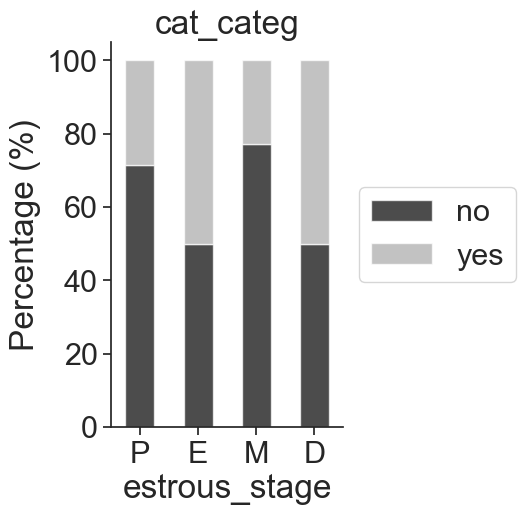

0.9146286513211039 0.08537134867889606


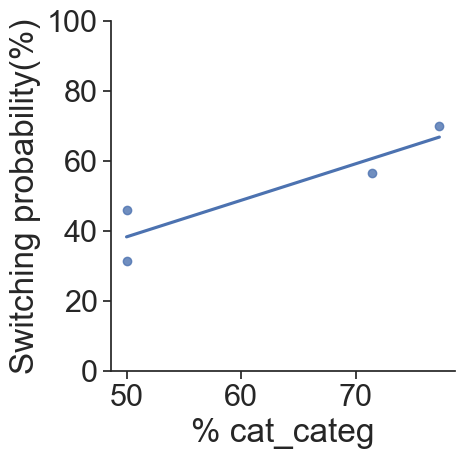

IH                 no  yes  All
estrous_stage                  
?                   0    4    4
D                   5   17   22
E                   0    8    8
M                  11   11   22
P                   5   16   21
VS to be stained    1    0    1
not taken           2    2    4
All                24   58   82
0.0352565677238345
IH estrous_stage         no         yes
4              P  23.809524   76.190476
2              E   0.000000  100.000000
3              M  50.000000   50.000000
1              D  22.727273   77.272727


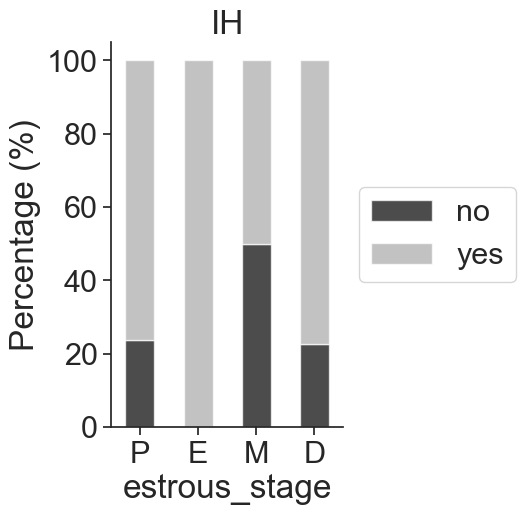

0.9665783850876507 0.033421614912349296


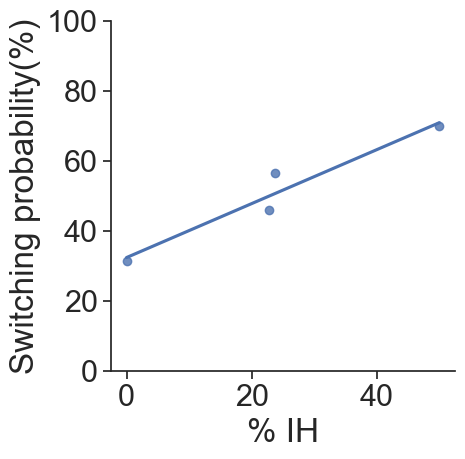

Adaptive           ?  no  yes  All
estrous_stage                     
?                  0   0    1    1
D                  0   4    6   10
E                  0   1    1    2
M                  0   7   11   18
P                  1   3    7   11
VS to be stained   0   0    1    1
All                1  15   27   43
0.9166519983189608
Adaptive estrous_stage         no        yes
4                    P  27.272727  63.636364
2                    E  50.000000  50.000000
3                    M  38.888889  61.111111
1                    D  40.000000  60.000000


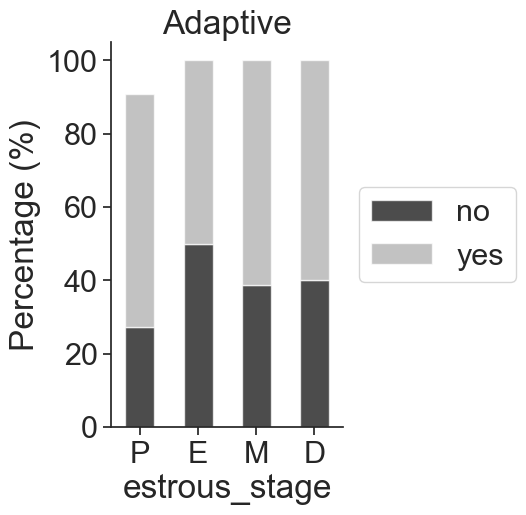

-0.6320737885969195 0.36792621140308046


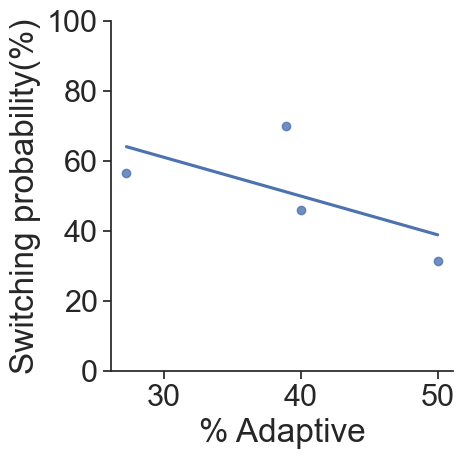

In [47]:
import scipy as sp
cols = ['no', 'yes']
ephys.loc[(ephys['Ih_at_-120mV'] == 0), 'IH']  = 'no'
ephys.loc[(ephys['Ih_at_-120mV'] >0 ), 'IH']  = 'yes'


estrous_df = pd.read_csv('../NPS_behaviour_analysis/generated_datasets/estrous_data.csv')
estrous_df.rename(columns = {'Unnamed: 0':'estrous_stage', '0':'switching probability'}, inplace = True)
ephys_pre = ephys[ephys.Behaviour_6hFD == 'Pre']

for column in ['cat_categ', 'IH', 'Adaptive']:
    esprop = proportion(ephys_pre, 'estrous_stage', column, cols)
    esprop['estrous_stage'] = pd.Categorical(esprop['estrous_stage'], ['P', 'E', 'M', 'D'])
    esprop = esprop.sort_values(by = ['estrous_stage']).dropna()
    prop_plot(esprop, 'estrous_stage')
    print(esprop)
    plt.title(column)
    plt.show()

    corr = pd.merge(esprop, estrous_df, on = 'estrous_stage')
    r, p = sp.stats.pearsonr(corr['switching probability'], corr['no'])
    print(r, p)

    sns.lmplot(x = 'no', y = 'switching probability', data = corr, ci = None)
    plt.ylim([0, 100])
    plt.xlabel(f'% {column}')
    plt.ylabel('Switching probability(%)')
    plt.savefig(f'output_figures/{column}_switching_corr.png', dpi = 300, bbox_inches = 'tight')
    plt.show()

IH                 no  yes  All
estrous_stage                  
?                   0    4    4
D                   5   17   22
E                   0    8    8
M                  11   11   22
P                   5   16   21
VS to be stained    1    0    1
not taken           2    2    4
All                24   58   82
0.0352565677238345
Adaptive           ?  no  yes  All
estrous_stage                     
?                  0   0    1    1
D                  0   4    6   10
E                  0   1    1    2
M                  0   7   11   18
P                  1   3    7   11
VS to be stained   0   0    1    1
All                1  15   27   43
0.9166519983189608
-0.284545136651464 0.715454863348536


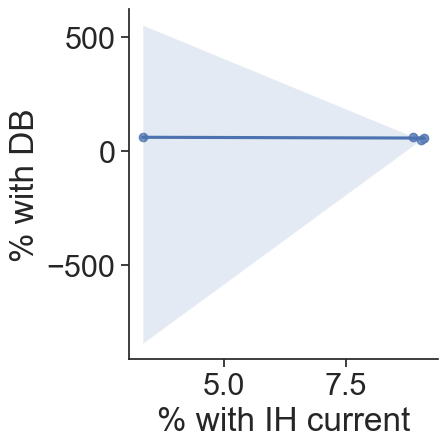

In [18]:

cols = ['no', 'yes']
estrous_stages = ['P', 'E', 'M', 'D']
ih_prop = proportion(ephys_pre, 'estrous_stage', 'IH', cols)
ih_est_mean = ephys_pre.groupby('estrous_stage')['Ih_at_-120mV'].mean().reset_index()
adaptive_prop = proportion(ephys_pre, 'estrous_stage', 'Adaptive', cols)
merged_df = pd.merge(ih_est_mean, adaptive_prop, on = 'estrous_stage')
merged_df = merged_df[merged_df.estrous_stage.isin(estrous_stages)]


r, p = sp.stats.pearsonr(merged_df['Ih_at_-120mV'], merged_df['yes'])
print(r, p)

sns.lmplot(x = 'Ih_at_-120mV', y = 'yes', data = merged_df)
# plt.ylim([0, /100])
plt.xlabel('% with IH current')
plt.ylabel('% with DB')
plt.show()